# ex-2 combined — total + component decomposition on `fl_plot`

Reproduces three of the ex-2 v2 component figures — **Total**, **Out-of-Subspace**,
**In-Subspace** (component-colored: box color = quantity, matching the band fills) —
then composes the new **combined** figure: the Total band row on top, with the two
component boxplot rows (out-of-subspace and in-subspace, no total-gap row) stacked
directly beneath it, each tinted with its band color.

Data loads from the shared `ex2v2_df_{p,n}.parquet` cache (regenerated in-notebook if
missing — same model / designs / seed as ex-2/ex-3, identical replicates).

In [1]:
import sys
from io import BytesIO
from pathlib import Path

REPO_ROOT = Path.cwd()
while not (REPO_ROOT / "sim").is_dir():
    if REPO_ROOT == REPO_ROOT.parent:
        raise FileNotFoundError("could not locate repo root (no 'sim' dir above cwd)")
    REPO_ROOT = REPO_ROOT.parent
for _p in (str(REPO_ROOT), str(REPO_ROOT / "sim")):
    if _p not in sys.path:
        sys.path.insert(0, _p)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import Image, display

from fl_plot import (grid, Row, BandStack, Band, MeanCI, BoxDist, Theme, THEME,
                     draw_zero_line, draw_box_dist, rep_dists)

DATA_DIR = REPO_ROOT / "nb_outputs"
OUT_DIR = REPO_ROOT / "nb_outputs" / "ex2v2-combined"
OUT_DIR.mkdir(parents=True, exist_ok=True)

FIG_FORMATS = ("pdf",)
SAVE_FIGS = False   # default: figures are NOT written to disk; enable one with out(..., save=True)


def out(stem, save=None):
    """out_path for grid(): OUT_DIR/stem when saving is on (globally via
    SAVE_FIGS, or per-figure via save=True), else None."""
    return OUT_DIR / stem if (SAVE_FIGS if save is None else save) else None


FACTOR_HATCHES = ("", "//", "xx", "..", "\\\\", "++")   # per-factor identity, colorless


def comp_theme(color, cmap="Blues"):
    return Theme(factor_colors=(color,) * 6, factor_cmaps=(cmap,) * 6,
                 factor_hatches=FACTOR_HATCHES,
                 ci_caps=dict(fmt="none", ecolor="black", elinewidth=0.0, capsize=0))


TOTAL_T = comp_theme("black")
OOS_T = comp_theme(THEME.oos_fill)                 # #4878a8 — matches the band fill
INSUB_T = comp_theme(THEME.insub_fill, "Oranges")  # #f28e2b — matches the band fill
_TAILS = r"(Factor Returns ~ $\mathcal{T}_6$, Idiosyncratic Returns ~ $\mathcal{T}_5$)"


def show(fig):
    buf = BytesIO()
    fig.savefig(buf, format="png", dpi=110, bbox_inches="tight")
    display(Image(data=buf.getvalue()))
    plt.close(fig)


def derive(df):
    """Theory limits + pathwise differences, from the recorded columns."""
    oos = df["measured_out_of_subspace"]
    return df.assign(
        theory_insub=df["rhs"] - df["floor"],
        gap=df["rhs"] - df["sin2_j"],
        diff_oos=df["floor"] - oos,
        diff_insub=(df["rhs"] - df["floor"]) - df["measured_in_subspace"],
        sin2_in=(df["sin2_j"] - oos) / (1.0 - oos),
    )

In [2]:
# ── Sweep machinery, carried verbatim from ex-2 v2 / ex-3 (no .py files touched) ──
# Generates (or loads) the shared nb_outputs/ex2v2_df_{p,n}.parquet cache: same model,
# designs, and seed as ex-2/ex-3, so the replicates are identical across notebooks.
from fl_experiment_setup import ModelSpec, DesignSpec, BaseExperiment
from fl_experiment_runner import run_experiment
from sim_theorem_partii import Eq6RHSAnalysis
from factor_lab.analyses.spectral import compute_true_eigenvalues
from factor_lab.analyses import compute_sine_alignment

# Canonical diagonal-Gram model (factor 1 market-like, c = [1.25, 1, 1]).
model = ModelSpec(
    k_factors=3,
    factor_vols=[0.16, 0.08, 0.06],
    beta_samplers=[
        {"distribution": "normal", "loc": 1.0, "scale": 0.5},
        {"distribution": "normal", "loc": 0.0, "scale": 1.0},
        {"distribution": "normal", "loc": 0.0, "scale": 1.0},
    ],
    idio_vol_sampler={"distribution": "constant", "value": 0.4},
)
HEAVY_TAIL = dict(
    factor_return_sampler={"distribution": "student_t", "df": 6, "loc": 0.0, "scale": 1.0},
    idio_return_sampler={"distribution": "student_t", "df": 5, "loc": 0.0, "scale": 1.0},
)
N_REPS, SEED = 1000, 20260511

design_p = DesignSpec(
    n_values=[63], p_values=[100, 500, 5000, 10000, 20000, 50000],
    n_reps=N_REPS, random_seed=SEED, sampling="nested", nest_time=True, **HEAVY_TAIL,
)
design_n = DesignSpec(
    n_values=[20, 30, 45, 60, 63, 90, 120, 180, 250], p_values=[3000],
    n_reps=N_REPS, random_seed=SEED, sampling="nested", nest_time=True, **HEAVY_TAIL,
)


class ObservableSpectrumAnalysis:
    """Observable side of Corollary 1: eigendecompose the n×n Gram G = Y^T Y, keep the full
    spectrum for the bulk average ℓ, and the top-k spikes θ_j (dual rescaled by 1/(n·p))."""

    def __init__(self, population_loading_directions_b_pop, center: bool = True):
        self.population_loading_directions_b_pop = population_loading_directions_b_pop
        self.center = center

    def analyze(self, context) -> dict:
        k = context.k
        Y = context.security_returns.T
        if self.center:
            Y = Y - Y.mean(axis=1, keepdims=True)
        p, n = Y.shape
        G = Y.T @ Y
        eigenvalues, eigenvectors = np.linalg.eigh(G)
        order = np.argsort(eigenvalues)[::-1]
        top_k = order[:k]
        sv = np.sqrt(np.maximum(eigenvalues[top_k], 0.0))
        H = (Y @ eigenvectors[:, top_k]) / np.where(sv > 1e-14, sv, 1.0)   # (p, k)
        sin2_angle, dist_sine = compute_sine_alignment(
            self.population_loading_directions_b_pop, H.T)

        dual = eigenvalues[order] / (n * p)
        theta = dual[:k]
        bulk = dual[k:n - 1] if self.center else dual[k:]
        ell = float(bulk.mean())
        return {"sin2_j": sin2_angle, "dist_sine": dist_sine,
                "sample_spike_eigenvalues_theta": theta,
                "sample_bulk_eigenvalue_average_ell": ell,
                "observable_floor_estimate": ell / theta}


class ObservableFloorExperiment(BaseExperiment):
    def __init__(self, center: bool = True):
        self.center = center

    def cell_setup(self, model, n: int, p: int):
        _, b_pop = compute_true_eigenvalues(model, model.k)
        return [ObservableSpectrumAnalysis(b_pop, center=self.center),
                Eq6RHSAnalysis(center=self.center)]

    def record(self, n: int, p: int, merged: dict) -> list[dict]:
        k = len(merged["sin2_j"])
        gap = merged["sin2_j"] - merged["rhs"]
        return [
            {"n": n, "p": p, "j": j + 1,
             "sin2_j": float(merged["sin2_j"][j]), "rhs": float(merged["rhs"][j]),
             "gap": float(gap[j]), "floor": float(merged["floor"][j]),
             "rotation": float(merged["rotation"][j]), "rho": float(merged["rhos"][j]),
             "theta_j_sample_eigenvalue": float(merged["sample_spike_eigenvalues_theta"][j]),
             "ell_bulk_eigenvalue_average": float(merged["sample_bulk_eigenvalue_average_ell"]),
             "observable_floor_estimate": float(merged["observable_floor_estimate"][j])}
            for j in range(k)]


class MeasuredDecompositionAnalysis(ObservableSpectrumAnalysis):
    """Adds the finite-p eq.(18) split: ‖Π⊥h_j‖² via projection of h_j onto col(b_pop)."""

    def analyze(self, context) -> dict:
        result = super().analyze(context)
        k = context.k
        Y = context.security_returns.T
        if self.center:
            Y = Y - Y.mean(axis=1, keepdims=True)
        G = Y.T @ Y
        eigenvalues, eigenvectors = np.linalg.eigh(G)
        top_k = np.argsort(eigenvalues)[::-1][:k]
        sv = np.sqrt(np.maximum(eigenvalues[top_k], 0.0))
        H = (Y @ eigenvectors[:, top_k]) / np.where(sv > 1e-14, sv, 1.0)
        coeffs = self.population_loading_directions_b_pop @ H           # (k, k)
        in_subspace = (coeffs ** 2).sum(axis=0)
        result["measured_out_of_subspace"] = 1.0 - in_subspace          # ‖Π⊥h_j‖²
        result["measured_in_subspace"] = result["sin2_j"] - (1.0 - in_subspace)
        result["angle_in_subspace"] = np.arccos(np.abs(np.diag(coeffs)) / np.sqrt(in_subspace))     # ∠(Π h_j, b_j), radians

        return result


class MeasuredDecompositionExperiment(ObservableFloorExperiment):
    def cell_setup(self, model, n: int, p: int):
        _, b_pop = compute_true_eigenvalues(model, model.k)
        return [MeasuredDecompositionAnalysis(b_pop, center=self.center),
                Eq6RHSAnalysis(center=self.center)]

    def record(self, n: int, p: int, merged: dict) -> list[dict]:
        rows = super().record(n, p, merged)
        for j, row in enumerate(rows):
            row["measured_out_of_subspace"] = float(merged["measured_out_of_subspace"][j])
            row["measured_in_subspace"] = float(merged["measured_in_subspace"][j])
            row["angle_in_subspace"] = float(merged["angle_in_subspace"][j])

        return rows


_pq_p, _pq_n = DATA_DIR / "ex2v2_df_p.parquet", DATA_DIR / "ex2v2_df_n.parquet"
if _pq_p.exists() and _pq_n.exists():
    df_p, df_n = pd.read_parquet(_pq_p), pd.read_parquet(_pq_n)
    print("loaded cached ex2v2 sweeps")
else:
    print("ex2v2 sweep cache missing — running sweeps (takes a few minutes)...")
    df_p = run_experiment(model, design_p, MeasuredDecompositionExperiment(), progress=True)
    df_n = run_experiment(model, design_n, MeasuredDecompositionExperiment(), progress=True)
    df_p.to_parquet(_pq_p)
    df_n.to_parquet(_pq_n)

df_p, df_n = derive(df_p), derive(df_n)
_SWEEPS = [(df_p, "p", "growing p, fixed n=63"), (df_n, "n", "growing n, fixed p=3000")]

# eq.(18) sanity, per replicate
for d, key, lab in _SWEEPS:
    recon = d["measured_out_of_subspace"] + d["measured_in_subspace"]
    print(f"{lab}: max |sin2_j − (oos + insub)| = {(d['sin2_j'] - recon).abs().max():.2e}")

loaded cached ex2v2 sweeps
growing p, fixed n=63: max |sin2_j − (oos + insub)| = 0.00e+00
growing n, fixed p=3000: max |sin2_j − (oos + insub)| = 0.00e+00


## Component figures (reproduced from ex-2 v2)

Total, out-of-subspace, in-subspace — each a band/limit top row over its pathwise
boxplot row, per sweep; box color = quantity, matching the band fills.

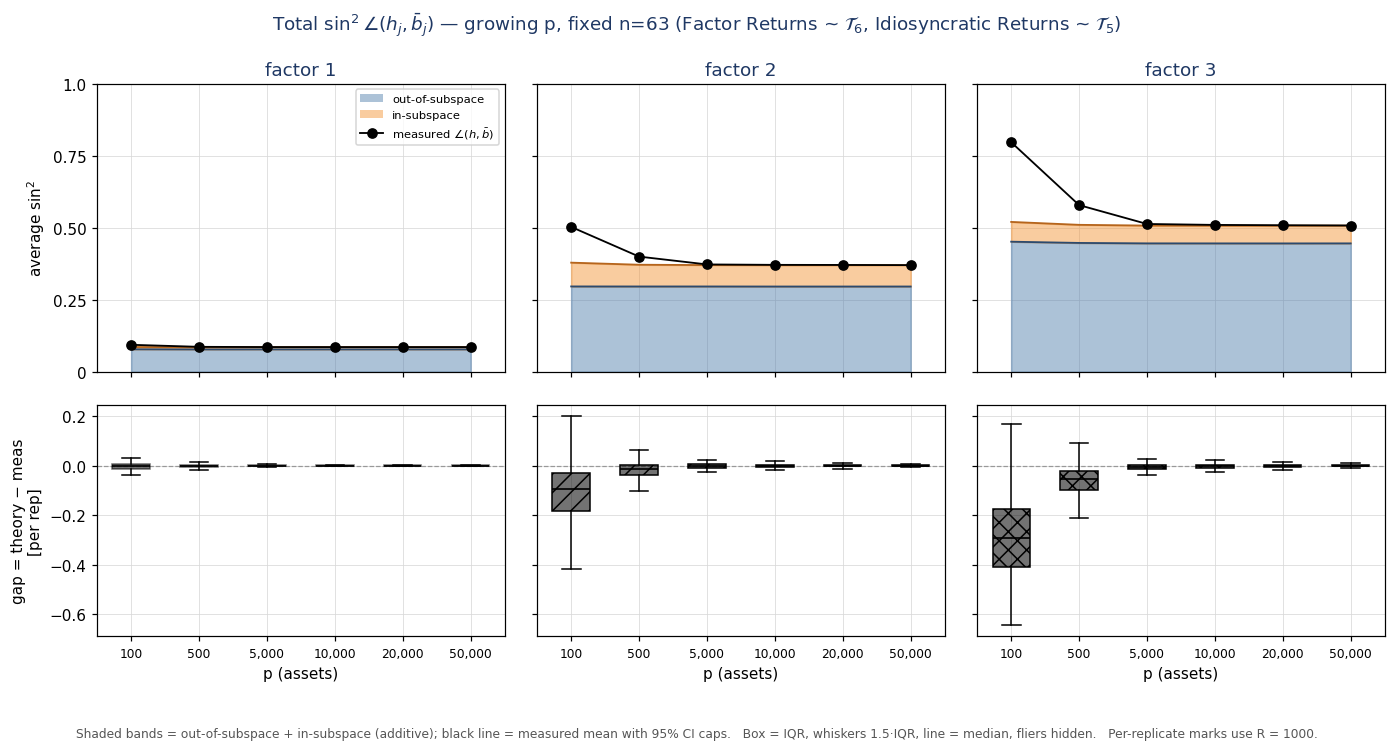

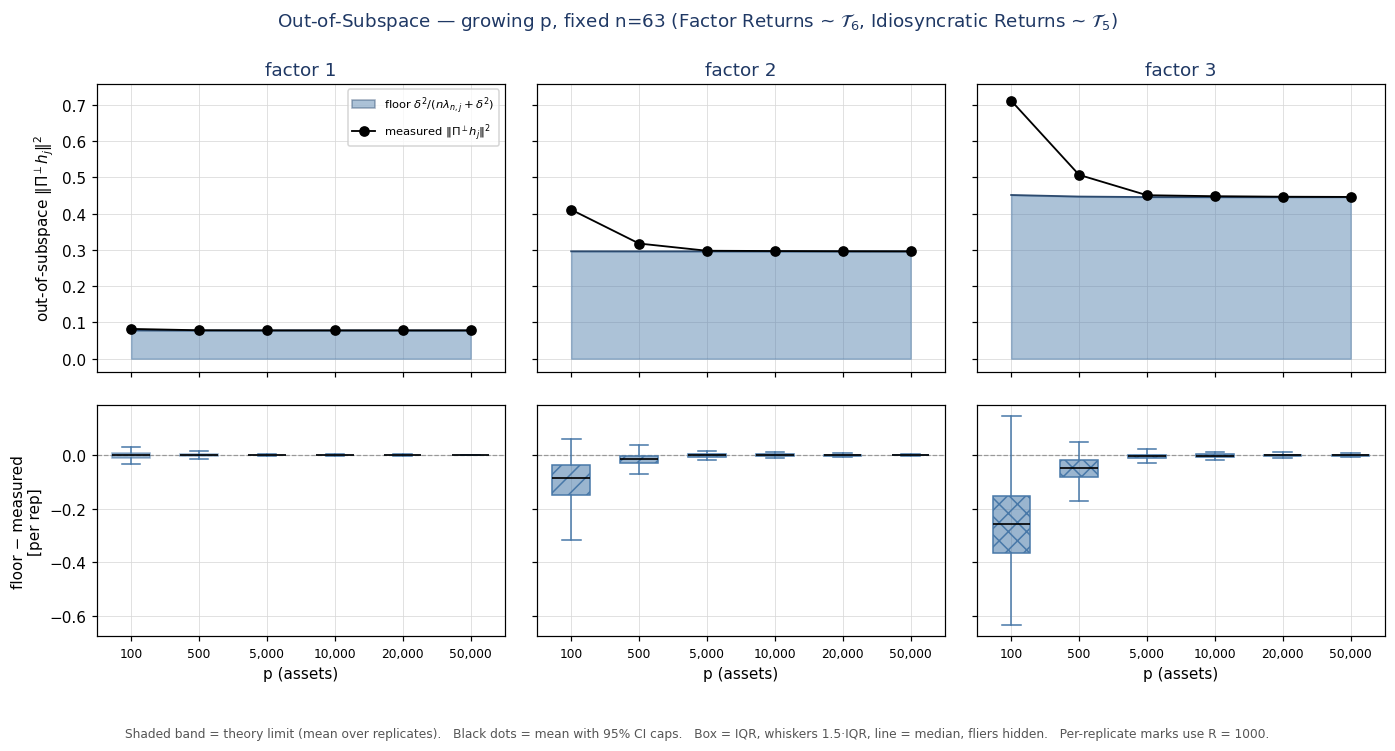

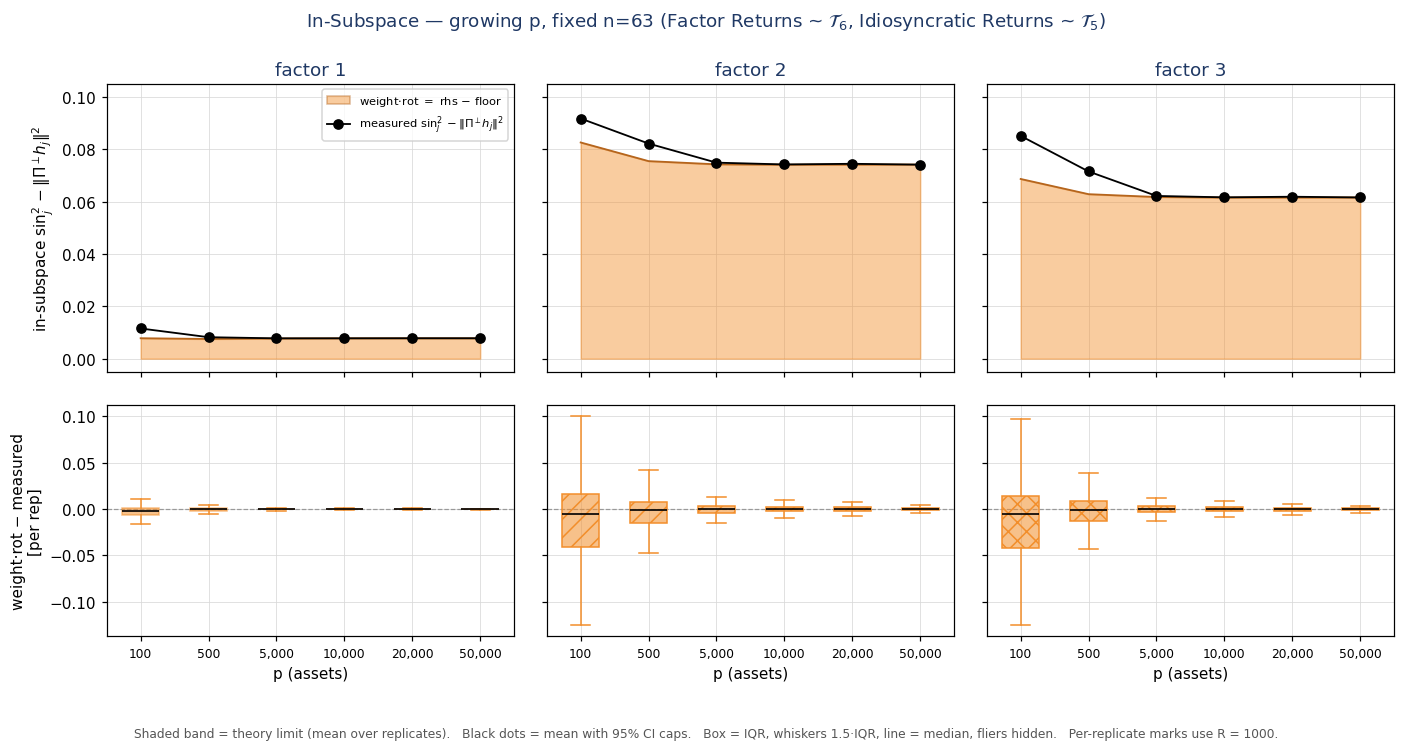

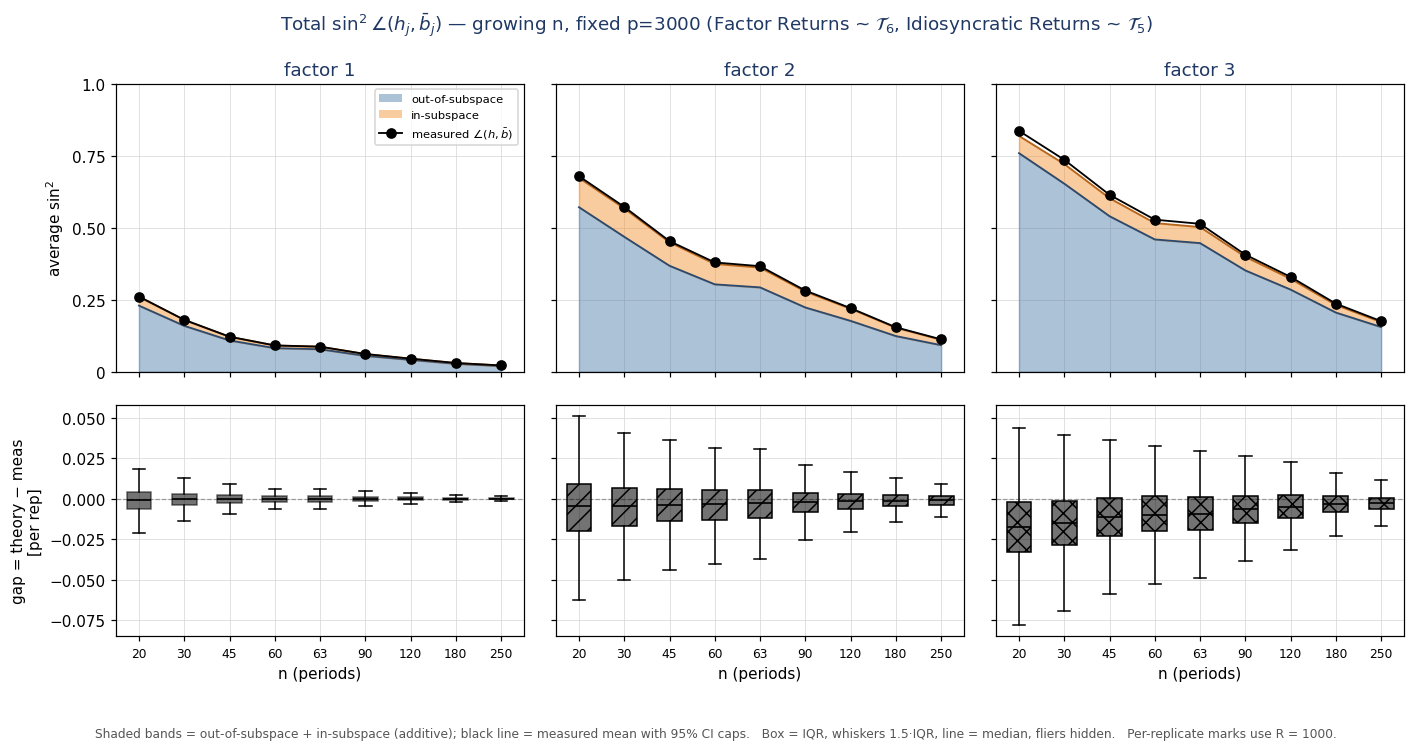

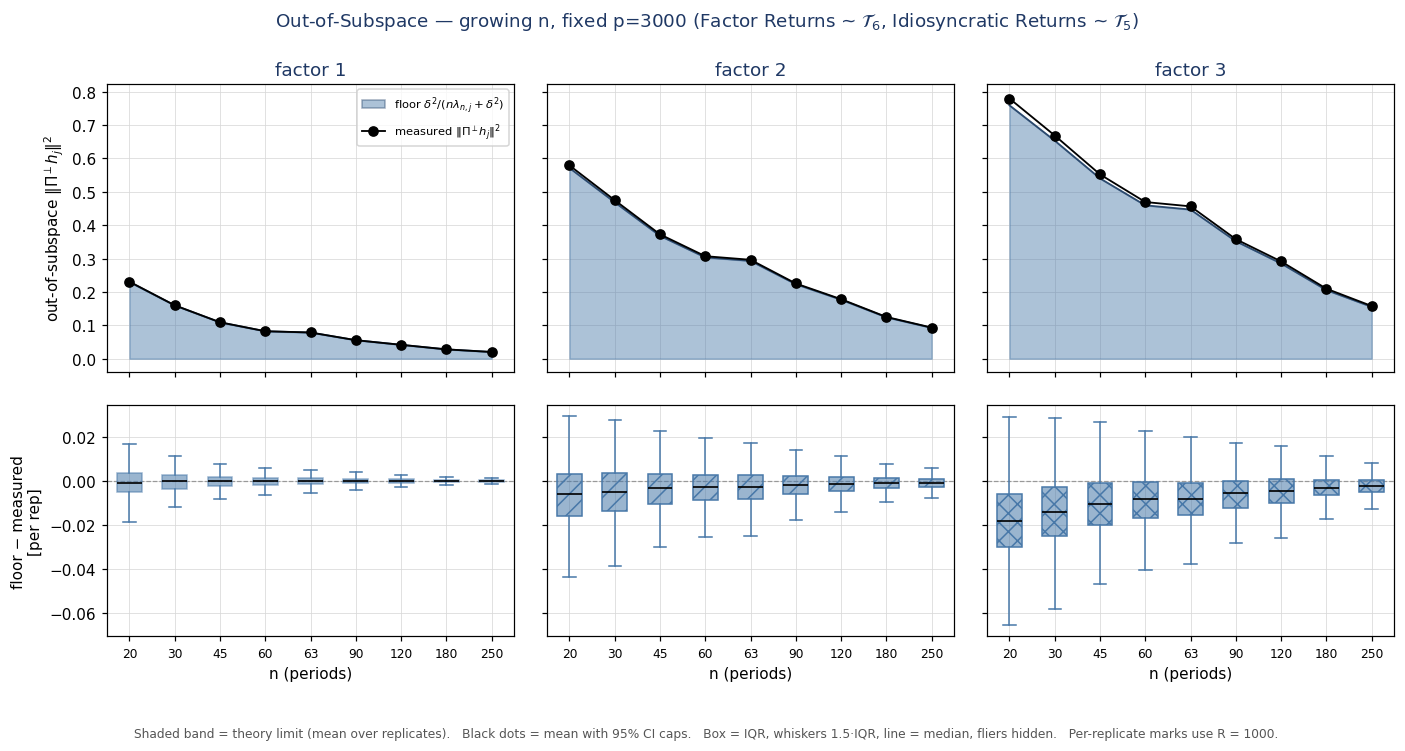

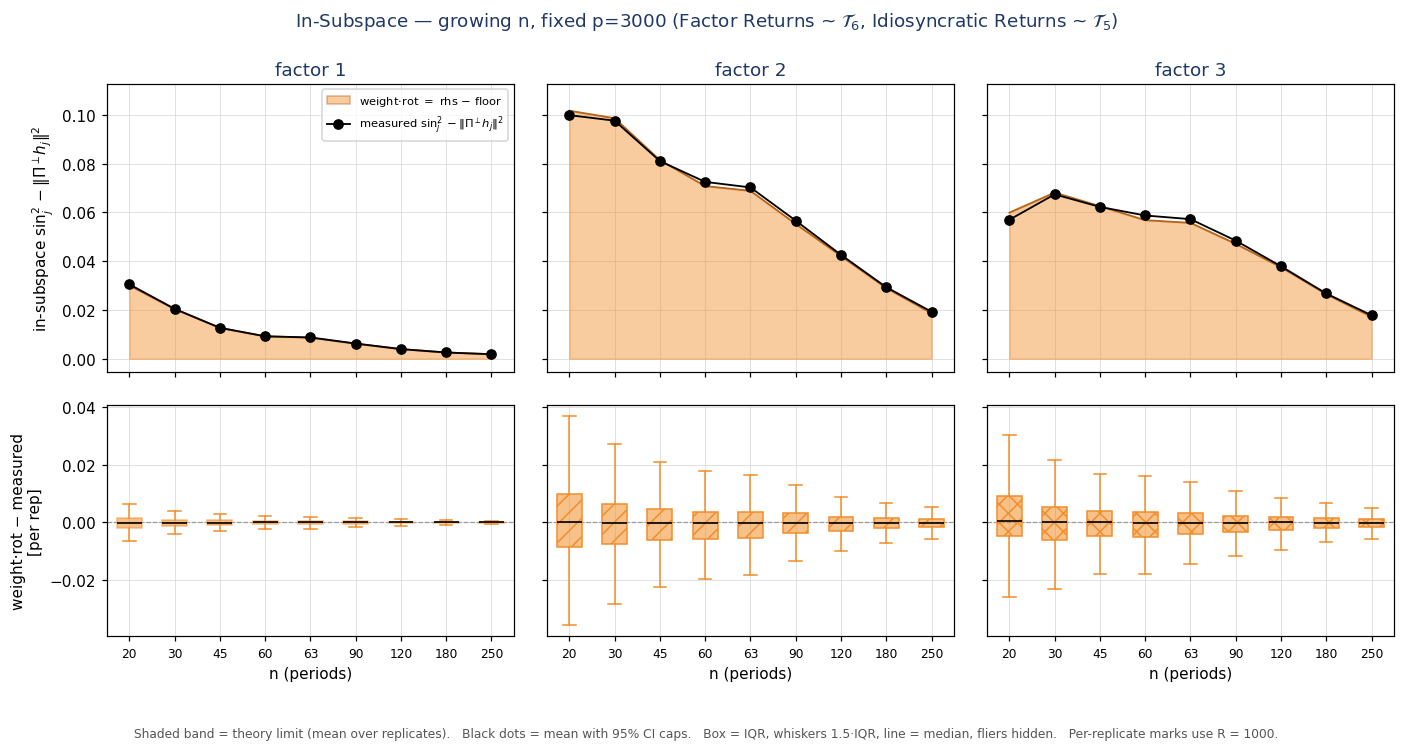

In [3]:
for d, key, lab in _SWEEPS:
    # 1 — total
    fig, _ = grid(d, key,
        rows=[Row(BandStack(labels=("out-of-subspace", "in-subspace",
                                    r"measured $\angle(h,\bar b)$")),
                  ylabel=r"average $\sin^2$", ylim=(0, 1),
                  yticks=THEME.sin2_ticks, height=1.0),
              Row(BoxDist("gap"), ylabel="gap = theory − meas\n[per rep]")],
        theme=TOTAL_T,
        suptitle=rf"Total $\sin^2\angle(h_j,\bar b_j)$ — {lab} {_TAILS}",
        formats=FIG_FORMATS, out_path=out(f"ex2c_comp1_total_{key}"))
    show(fig)
    # 2 — out-of-subspace
    fig, _ = grid(d, key,
        rows=[Row([Band("floor", label=r"floor $\delta^2/(n\lambda_{n,j}+\delta^2)$"),
                   MeanCI("measured_out_of_subspace",
                          label=r"measured $\Vert\Pi^{\perp}h_j\Vert^2$")],
                  ylabel=r"out-of-subspace $\Vert\Pi^{\perp}h_j\Vert^2$", height=1.0),
              Row(BoxDist("diff_oos"), ylabel="floor − measured\n[per rep]")],
        theme=OOS_T, suptitle=rf"Out-of-Subspace — {lab} {_TAILS}",
        formats=FIG_FORMATS, out_path=out(f"ex2c_comp2_oos_{key}"))
    show(fig)
    # 3 — in-subspace
    fig, _ = grid(d, key,
        rows=[Row([Band("theory_insub", label=r"weight$\cdot$rot $=$ rhs $-$ floor",
                        fill=THEME.insub_fill, line=THEME.insub_line),
                   MeanCI("measured_in_subspace",
                          label=r"measured $\sin^2_j - \Vert\Pi^{\perp}h_j\Vert^2$")],
                  ylabel=r"in-subspace $\sin^2_j-\Vert\Pi^{\perp}h_j\Vert^2$", height=1.0),
              Row(BoxDist("diff_insub"), ylabel="weight·rot − measured\n[per rep]")],
        theme=INSUB_T, suptitle=rf"In-Subspace — {lab} {_TAILS}",
        formats=FIG_FORMATS, out_path=out(f"ex2c_comp3_insub_{key}"))
    show(fig)

## Combined figure

The Total figure's band row on top; directly beneath, the two component boxplot rows —
out-of-subspace (blue) and in-subspace (orange) — each tinted to match its band fill.
The total-gap boxplot row is intentionally omitted (per replicate it is exactly the sum
of the two component rows).

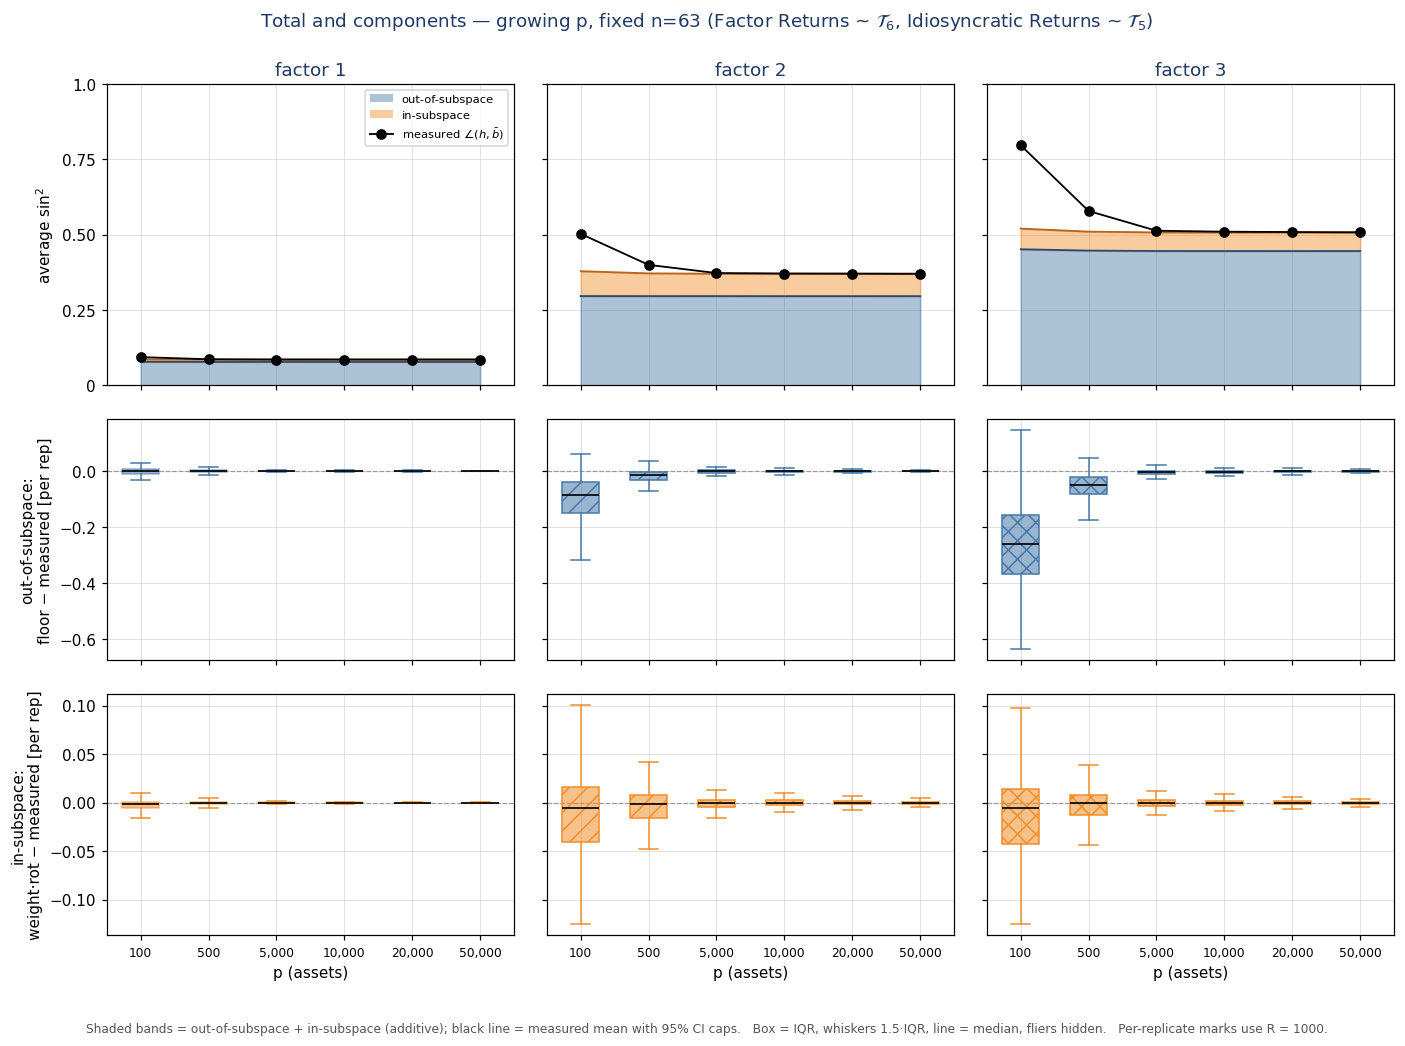

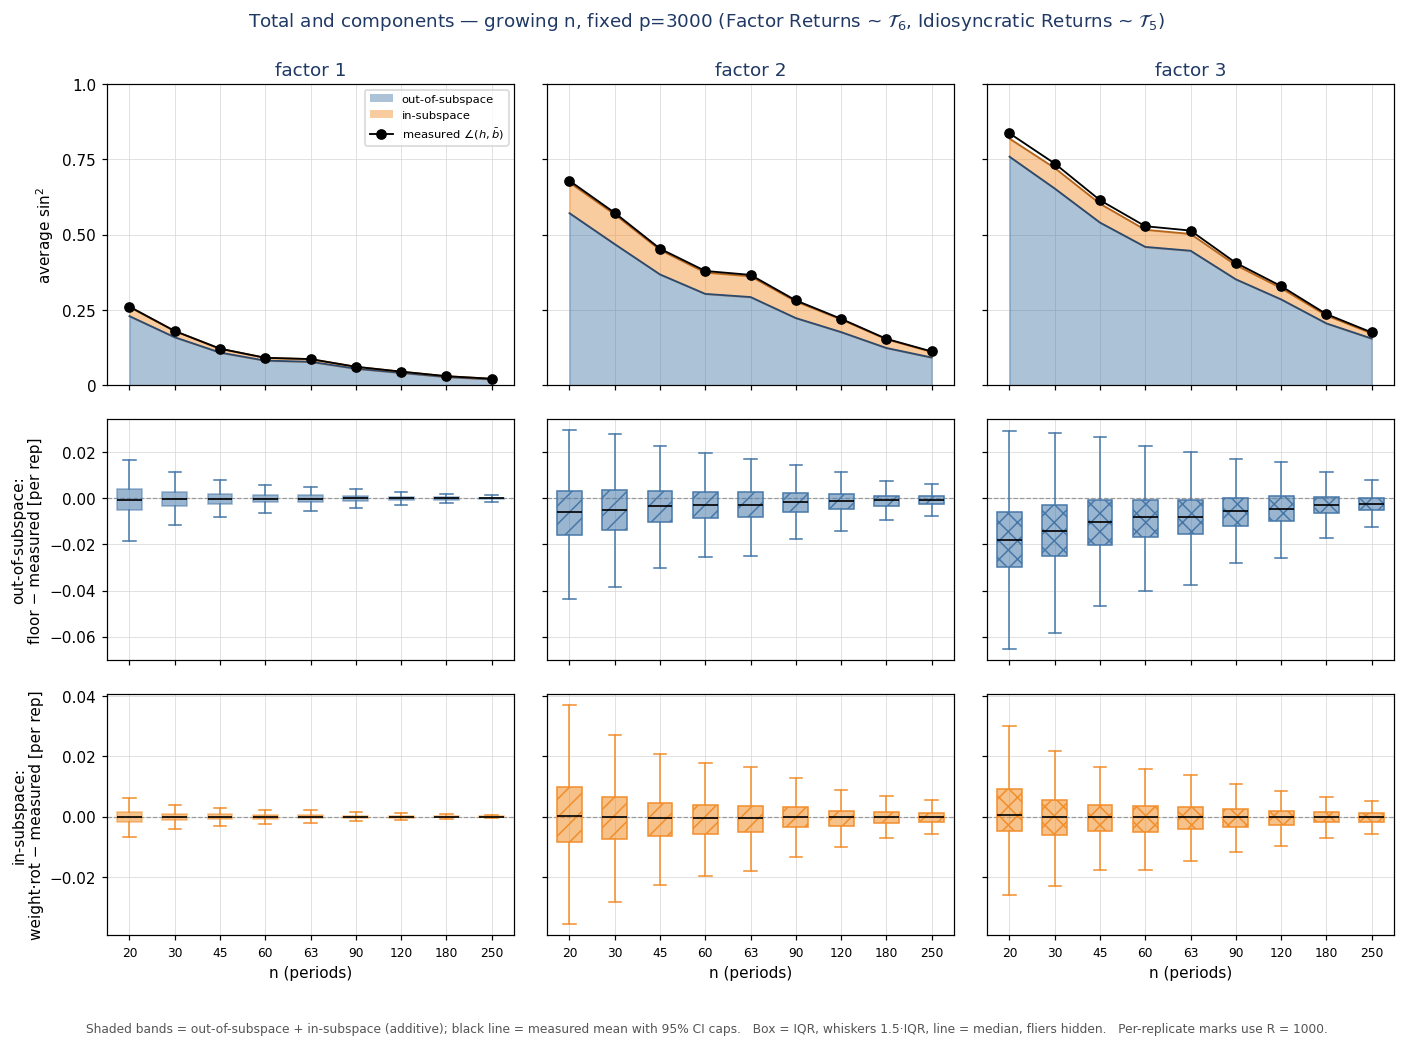

In [4]:
class TintedBoxDist(BoxDist):
    """BoxDist in a fixed color (ties a component's box row to its band fill),
    keeping the per-factor hatch identity from the theme."""

    def __init__(self, col, color, **kw):
        super().__init__(col, **kw)
        self.color = color

    def draw(self, ax, ax_spec, sub, j_idx, theme):
        if self.zero_line:
            draw_zero_line(ax, theme)
        draw_box_dist(ax, ax_spec, rep_dists(sub, ax_spec, self.col),
                      self.color, width=self.width,
                      hatch=theme.factor_hatch(j_idx), theme=theme)


for d, key, lab in _SWEEPS:
    fig, _ = grid(d, key,
        rows=[Row(BandStack(labels=("out-of-subspace", "in-subspace",
                                    r"measured $\angle(h,\bar b)$")),
                  ylabel=r"average $\sin^2$", ylim=(0, 1),
                  yticks=THEME.sin2_ticks, height=1.0),
              Row(TintedBoxDist("diff_oos", THEME.oos_fill),
                  ylabel="out-of-subspace:\nfloor − measured [per rep]"),
              Row(TintedBoxDist("diff_insub", THEME.insub_fill),
                  ylabel="in-subspace:\nweight·rot − measured [per rep]")],
        theme=TOTAL_T,
        suptitle=rf"Total and components — {lab} {_TAILS}",
        formats=FIG_FORMATS, out_path=out(f"ex2c_combined_{key}"))
    show(fig)

## Combined, grouped — two rows

Same content as the combined figure, compressed to two rows: the Total band row on top,
and a single boxplot row where the three per-replicate differences — **total**
(theory − meas, black), **out-of-subspace** (floor − meas, blue), and **in-subspace**
(weight·rot − meas, orange) — sit side-by-side at each swept value. All three follow the
same theory − measured sign convention, so they share one scale; per replicate,
total = out-of-subspace + in-subspace. Box color = quantity (legend on the first panel).

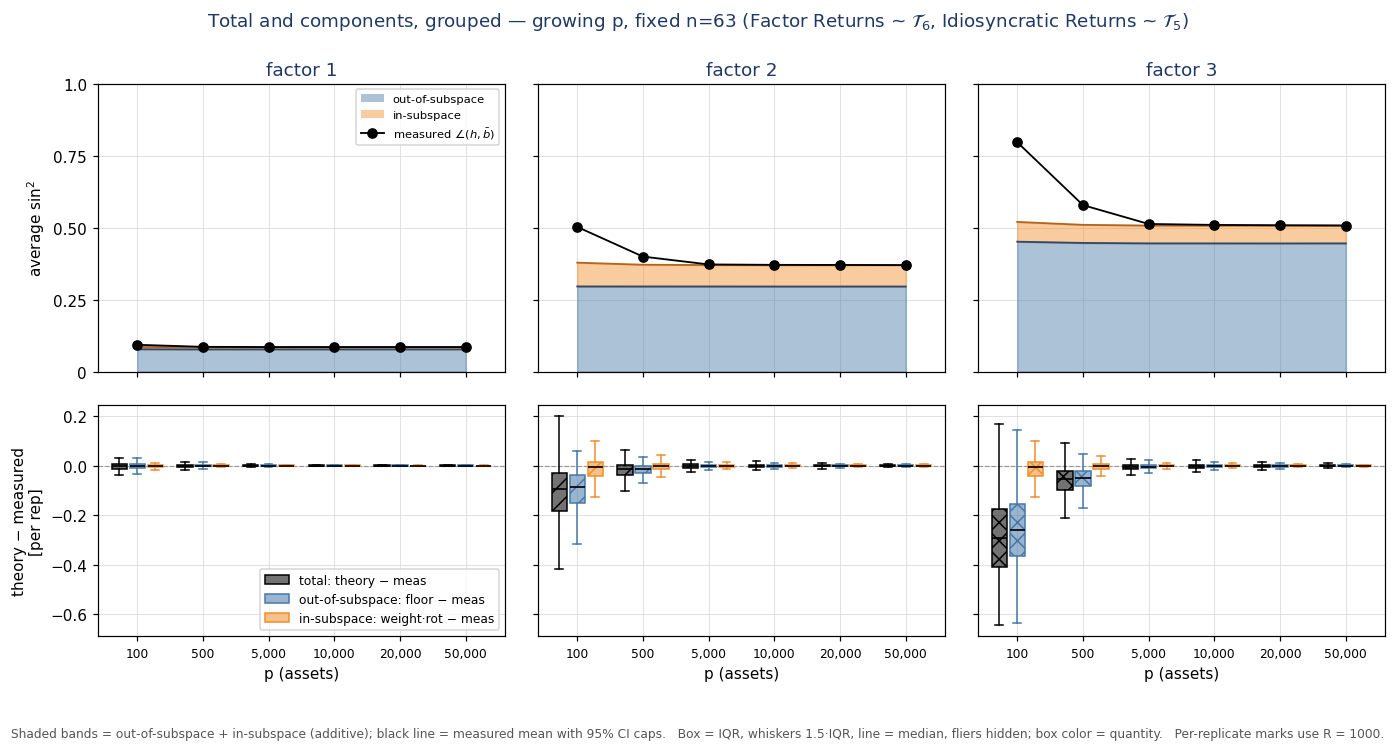

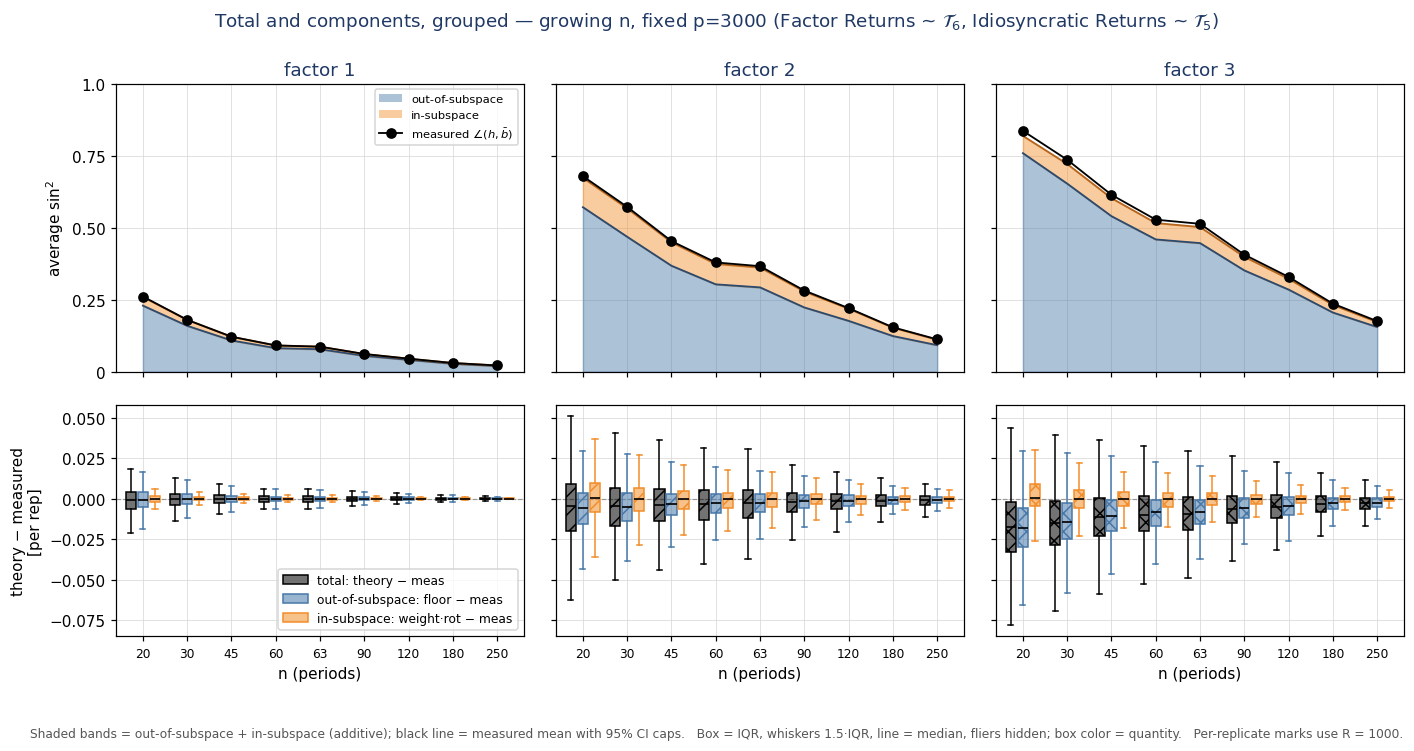

In [5]:
import matplotlib.colors as mcolors
from matplotlib.patches import Patch


class GroupedBoxDist:
    """Several per-rep quantities as side-by-side boxplots at each swept value,
    colored by quantity (specs = [(col, color, label), ...]); keeps the theme's
    per-factor hatch identity. Styling mirrors fl_plot.draw_box_dist."""

    caption = ("box = IQR, whiskers 1.5·IQR, line = median, fliers hidden; "
               "box color = quantity")

    def __init__(self, specs, *, group_width=0.82, zero_line=True):
        self.specs, self.group_width, self.zero_line = specs, group_width, zero_line

    def draw(self, ax, ax_spec, sub, j_idx, theme):
        if self.zero_line:
            draw_zero_line(ax, theme)
        k = len(self.specs)
        w = self.group_width / k
        hatch = theme.factor_hatch(j_idx)
        for gi, (col, color, _) in enumerate(self.specs):
            pos = [x + (gi - (k - 1) / 2) * w for x in ax_spec.x]
            ax.boxplot(
                rep_dists(sub, ax_spec, col), positions=pos, widths=w * 0.85,
                patch_artist=True, showfliers=False, zorder=3,
                medianprops=dict(color="black", lw=1.1),
                boxprops=dict(facecolor=mcolors.to_rgba(color, 0.55),
                              edgecolor=color, hatch=hatch),
                whiskerprops=dict(color=color), capprops=dict(color=color))
        ax.set_xlim(ax_spec.x[0] - 0.6, ax_spec.x[-1] + 0.6)
        ax.set_xticks(ax_spec.x, ax_spec.cats, fontsize=theme.tick_fontsize)

    def legend_handles(self, theme):
        return [Patch(facecolor=mcolors.to_rgba(c, 0.55), edgecolor=c, label=l)
                for _, c, l in self.specs]


BOX_SPECS = [("gap", "black", "total: theory − meas"),
             ("diff_oos", THEME.oos_fill, "out-of-subspace: floor − meas"),
             ("diff_insub", THEME.insub_fill, "in-subspace: weight·rot − meas")]

for d, key, lab in _SWEEPS:
    grouped = GroupedBoxDist(BOX_SPECS)
    fig, axes = grid(d, key,
        rows=[Row(BandStack(labels=("out-of-subspace", "in-subspace",
                                    r"measured $\angle(h,\bar b)$")),
                  ylabel=r"average $\sin^2$", ylim=(0, 1),
                  yticks=THEME.sin2_ticks, height=1.0),
              Row(grouped, ylabel="theory − measured\n[per rep]")],
        theme=TOTAL_T,
        suptitle=rf"Total and components, grouped — {lab} {_TAILS}",
        formats=FIG_FORMATS, out_path=out(f"ex2c_combined_grouped_{key}"))
    axes[1, 0].legend(handles=grouped.legend_handles(TOTAL_T), fontsize=8,
                      loc="lower right")
    show(fig)